In [228]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from pathlib import Path
import json
from scipy import ndimage
from scipy.signal import correlate2d
from scipy.optimize import minimize
import pandas as pd
import copy
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


In [88]:
# ------------------------------------------------------------------
# 2)  Define shift detection functions
# ------------------------------------------------------------------

# def find_shift_correlation(image1, image2, upsample_factor=10):
#     """
#     Find the shift between two images using cross-correlation.
    
#     Parameters:
#     -----------
#     image1 : ndarray
#         Reference image
#     image2 : ndarray
#         Image to be aligned
#     upsample_factor : int
#         Factor for subpixel precision (higher = more precise but slower)
    
#     Returns:
#     --------
#     shift : tuple
#         (y_shift, x_shift) in pixels
#     correlation : float
#         Maximum correlation value
#     """
#     from skimage.registration import phase_cross_correlation
#     from scipy.ndimage import shift as nd_shift
    
#     # Use phase cross-correlation for subpixel accuracy
#     try:
#         # Try using skimage if available
#         shift, error, diffphase = phase_cross_correlation(
#             image1, image2, upsample_factor=upsample_factor
#         )
#         correlation = 1 - error  # Convert error to correlation metric
#     except ImportError:
#         # Fallback to scipy correlation
#         # Normalize images
#         img1_norm = (image1 - np.mean(image1)) / np.std(image1)
#         img2_norm = (image2 - np.mean(image2)) / np.std(image2)
        
#         # Compute cross-correlation
#         correlation = correlate2d(img1_norm, img2_norm, mode='same', boundary='fill')
        
#         # Find peak
#         y_peak, x_peak = np.unravel_index(np.argmax(correlation), correlation.shape)
        
#         # Convert to shift (relative to center)
#         shift = (y_peak - image1.shape[0]//2, x_peak - image1.shape[1]//2)
#         correlation = np.max(correlation)
    
#     return shift, correlation

def find_shift_correlation(image1, image2, xmin=None, xmax=None, ymin=None, ymax=None):
    """Zumeng Version"""
    ny, nx = image2.shape[0], image2.shape[1]
    if xmin is None:
        xmin = 0
    if xmax is None:
        xmax = nx-1
    if ymin is None:
        ymin = 0
    if ymax is None:
        ymax = ny-1

    y, x = np.arange(0, ny, dtype=float), np.arange(0, nx, dtype=float)
    # f0 = interpolate.interp2d(x, y, reference_map, kind='cubic')
    f1 = interpolate.RectBivariateSpline(y, x, image1)
    # https://scipython.com/book/chapter-8-scipy/examples/two-dimensional-interpolation-with-scipyinterpolaterectbivariatespline/
    # for some reason x and y in interp2d and rectbivariatespline is revesed

    def shift_function(info, dx, dy):
        xmin, xmax = int(info[0]), int(info[1])
        ymin, ymax = int(info[2]), int(info[3])
        x = np.linspace(xmin, xmax, xmax - xmin + 1)
        y = np.linspace(ymin, ymax, ymax - ymin + 1)
        # go0 = f0(x-dx, y-dy)
        go1 = f1(y-dy, x-dx)
        # print(go0.shape, go1.shape, 'fit')
        return go1.ravel()

    to_fit = image2[ymin:ymax+1, xmin:xmax+1].ravel()
    if np.isnan(np.sum(to_fit)):
        return None
    popt, pcov = opt.curve_fit(shift_function,
                                [xmin, xmax, ymin, ymax],
                                to_fit,
                                p0=(0, 0))
    shift = popt
    # shift = (float(shift[1]), float(shift[0]))
    print(shift)
    return shift, 0

def apply_shift(image, shift):
    """
    Apply a shift to an image using spline interpolation.
    
    Parameters:
    -----------
    image : ndarray
        Input image
    shift : tuple
        (y_shift, x_shift) in pixels
    
    Returns:
    --------
    shifted_image : ndarray
        Shifted image
    """
    return ndimage.shift(image, shift, mode='constant', cval=0)

def apply_shift_cube(data_cube, shifts):
    """
    Apply a shift to a data cube.
    """
    for i in range(data_cube.shape[0]):
        data_cube[i] = apply_shift(data_cube[i], shifts[i])
    return data_cube

def analyze_all_shifts(data_cube, reference_idx=0, show_plots=True):
    """
    Analyze shifts for all images in the data cube relative to a reference.
    
    Parameters:
    -----------
    data_cube : ndarray
        3D array of images (n_images, height, width)
    reference_idx : int
        Index of the reference image
    show_plots : bool
        Whether to show diagnostic plots
    
    Returns:
    --------
    shifts : list
        List of (y_shift, x_shift) tuples
    correlations : list
        List of correlation values
    aligned_cube : ndarray
        Aligned data cube
    """
    n_images = data_cube.shape[0]
    reference = data_cube[reference_idx]
    
    shifts = []
    correlations = []
    aligned_cube = np.zeros_like(data_cube)
    
    print(f"\nAnalyzing shifts relative to image {reference_idx} (HWP {angles[reference_idx]}°)")
    print("-" * 60)
    
    for i in range(n_images):
        if i == reference_idx:
            shifts.append((0.0, 0.0))
            correlations.append(1.0)
            aligned_cube[i] = data_cube[i]
            print(f"Image {i:2d} (HWP {angles[i]:5.1f}°): Reference image")
        else:
            shift, corr = find_shift_correlation(reference, data_cube[i])
            shifts.append(shift)
            correlations.append(corr)
            
            # Apply shift to align the image
            aligned_cube[i] = apply_shift(data_cube[i], shift)  # Negative to align
            
            # Convert shifts to physical units (voltage)
            x_shift_v = shift[1] * (x_vals[1] - x_vals[0])
            y_shift_v = shift[0] * (y_vals[1] - y_vals[0])
            
            print(f"Image {i:2d} (HWP {angles[i]:5.1f}°): "
                  f"Shift = ({shift[0]:6.2f}, {shift[1]:6.2f}) pixels, "
                  f"({y_shift_v:7.4f}, {x_shift_v:7.4f}) V, "
                  f"Corr = {corr:.3f}")
    
    if show_plots:
        plot_shift_analysis(data_cube, aligned_cube, shifts, correlations)
    
    return shifts, correlations, aligned_cube

def plot_shift_analysis(original_cube, aligned_cube, shifts, correlations):
    """
    Create diagnostic plots for shift analysis.
    """
    n_images = len(shifts)
    
    # Figure 1: Shift vectors and correlation values
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot shift vectors
    x_shifts = [s[1] for s in shifts]
    y_shifts = [s[0] for s in shifts]
    
    ax1.scatter(x_shifts, y_shifts, c=angles[:n_images], cmap='viridis', s=100)
    ax1.plot(x_shifts, y_shifts, 'k-', alpha=0.3)
    ax1.scatter(0, 0, c='red', s=200, marker='x', linewidth=3, label='Reference')
    
    # Add angle labels
    for i, (x, y, ang) in enumerate(zip(x_shifts, y_shifts, angles[:n_images])):
        ax1.annotate(f'{ang:.0f}°', (x, y), xytext=(3, 3), 
                    textcoords='offset points', fontsize=8)
    
    ax1.set_xlabel('X Shift (pixels)')
    ax1.set_ylabel('Y Shift (pixels)')
    ax1.set_title('Image Shifts Relative to Reference')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.axis('equal')
    
    # Plot correlation values
    ax2.plot(angles[:n_images], correlations, 'o-')
    ax2.set_xlabel('HWP Angle (degrees)')
    ax2.set_ylabel('Correlation with Reference')
    ax2.set_title('Alignment Quality')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Figure 2: Before and after alignment comparison
    fig2, axes = plt.subplots(2, 6, figsize=(36, 12))
    
    # Select 6 evenly spaced images to show
    indices = np.linspace(0, n_images-1, 6, dtype=int)
    
    vmax = np.percentile(original_cube, 95)
    vmin = np.percentile(original_cube, 5)
    norm = PowerNorm(gamma=0.7, vmin=vmin, vmax=vmax)
    
    for idx, i in enumerate(indices):
        # Original images
        axes[0, idx].imshow(original_cube[i], cmap='inferno', norm=norm)
        axes[0, idx].set_title(f'Original\nHWP {angles[i]:.0f}°', fontsize=9)
        axes[0, idx].axis('off')
        
        # Aligned images
        axes[1, idx].imshow(aligned_cube[i], cmap='inferno', norm=norm)
        axes[1, idx].set_title(f'Aligned\nShift: ({shifts[i][0]:.1f}, {shifts[i][1]:.1f})', fontsize=9)
        axes[1, idx].axis('off')
    
    plt.suptitle('Before and After Alignment', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Figure 3: Drift over time
    fig3, (ax3, ax4) = plt.subplots(2, 1, figsize=(10, 8))
    
    # Calculate cumulative distance
    cumulative_dist = [0]
    for i in range(1, n_images):
        dist = np.sqrt((x_shifts[i] - x_shifts[i-1])**2 + 
                      (y_shifts[i] - y_shifts[i-1])**2)
        cumulative_dist.append(cumulative_dist[-1] + dist)
    
    # X and Y drift over angle sequence
    ax3.plot(angles[:n_images], x_shifts, 'o-', label='X shift', color='blue')
    ax3.plot(angles[:n_images], y_shifts, 's-', label='Y shift', color='red')
    ax3.set_xlabel('HWP Angle (degrees)')
    ax3.set_ylabel('Shift (pixels)')
    ax3.set_title('X and Y Shifts vs HWP Angle')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # Cumulative drift
    ax4.plot(angles[:n_images], cumulative_dist, 'o-', color='green')
    ax4.set_xlabel('HWP Angle (degrees)')
    ax4.set_ylabel('Cumulative Drift (pixels)')
    ax4.set_title('Total Cumulative Drift During Measurement')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def create_shift_report(shifts, correlations, angles_used):
    """
    Create a summary report of the shift analysis.
    """
    # Convert to voltage units
    x_pixel_size = x_vals[1] - x_vals[0]
    y_pixel_size = y_vals[1] - y_vals[0]
    
    # Create DataFrame for nice display
    df = pd.DataFrame({
        'HWP Angle (°)': angles_used,
        'Y Shift (px)': [s[0] for s in shifts],
        'X Shift (px)': [s[1] for s in shifts],
        'Y Shift (V)': [s[0] * y_pixel_size for s in shifts],
        'X Shift (V)': [s[1] * x_pixel_size for s in shifts],
        'Total Shift (px)': [np.sqrt(s[0]**2 + s[1]**2) for s in shifts],
        'Correlation': correlations
    })
    
    print("\n" + "="*60)
    print("SHIFT ANALYSIS SUMMARY")
    print("="*60)
    print(df.to_string(index=False))
    
    print("\n" + "-"*60)
    print("STATISTICS:")
    print("-"*60)
    print(f"Maximum X shift: {df['X Shift (px)'].abs().max():.2f} pixels "
          f"({df['X Shift (V)'].abs().max():.4f} V)")
    print(f"Maximum Y shift: {df['Y Shift (px)'].abs().max():.2f} pixels "
          f"({df['Y Shift (V)'].abs().max():.4f} V)")
    print(f"Maximum total shift: {df['Total Shift (px)'].max():.2f} pixels")
    print(f"Average correlation: {df['Correlation'].mean():.3f}")
    print(f"Minimum correlation: {df['Correlation'].min():.3f}")
    
    return df

# ------------------------------------------------------------------
# 3)  Run the shift analysis
# ------------------------------------------------------------------

# Analyze shifts for the first 11 images
# num_analyze = min(11, len(angles))
# data_subset = sample_cube[:num_analyze]
# angles_subset = angles[:num_analyze]

# # Perform shift analysis
# shifts, correlations, aligned_cube = analyze_all_shifts(
#     data_subset, 
#     reference_idx=0,  # Use first image as reference
#     show_plots=True
# )

# # Create summary report
# shift_df = create_shift_report(shifts, correlations, angles_subset)

# Optional: Save the aligned data
# np.save(f"{batch_name}_aligned_cube.npy", aligned_cube)

# Optional: Save shift data to CSV
# shift_df.to_csv(f"{batch_name}_shift_analysis.csv", index=False)

In [222]:
# ------------------------------------------------------------------
# 2)  Function to extract zoomed region data
# ------------------------------------------------------------------
def extract_zoom_data(x, y, pixel_num=20, reflection_data=None, count_data=None, angle_indices=None, data_cube=None):
    """
    Extract zoomed-in region data from the SHG maps.
    
    Parameters:
    -----------
    x : float
        X-coordinate (voltage) of the center point
    y : float
        Y-coordinate (voltage) of the center point
    pixel_num : int
        Size of the square region to extract (pixel_num x pixel_num pixels)
    angle_indices : list or None
        List of angle indices to extract. If None, extracts first 11 angles
    data_cube : ndarray or None
        Data cube to extract from. If None, uses global sample_cube
    reflection_data : ndarray or None
        Reflection data. If None, uses global ai0_data
    
    Returns:
    --------
    dict containing:
        - 'zoomed_data': list of zoomed regions for each angle
        - 'reflection_zoomed': zoomed reflection data
        - 'extent': [x_min, x_max, y_min, y_max] in voltage units
        - 'pixel_bounds': dict with x_min, x_max, y_min, y_max pixel indices
        - 'center': (x, y) center coordinates
        - 'angle_indices': indices used
        - 'angles': corresponding angle values
    """
    
    # Use global variables if not provided
    if count_data is None:
        count_data = count_data
    if reflection_data is None:
        reflection_data = reflection_data
    
    # Find the nearest pixel indices for the given coordinates
    x_idx = np.argmin(np.abs(x_vals - x))
    y_idx = np.argmin(np.abs(y_vals - y))
    
    # Calculate the pixel bounds (with boundary checks)
    half_size = pixel_num // 2
    x_min = max(0, x_idx - half_size)
    x_max = min(len(x_vals), x_idx + half_size)
    y_min = max(0, y_idx - half_size)
    y_max = min(len(y_vals), y_idx + half_size)
    
    # Extract the corresponding voltage ranges for the extent
    x_extent = [x_vals[x_min], x_vals[x_max-1]]
    y_extent = [y_vals[y_min], y_vals[y_max-1]]
    extent = [x_extent[0], x_extent[1], y_extent[0], y_extent[1]]
    
    # Determine which angles to extract
    if angle_indices is None:
        angle_indices = list(range(min(11, len(angles))))
    
    # Extract zoomed regions for all selected angles
    zoomed_data = count_data[:, y_min:y_max, x_min:x_max]
    
    # Extract the reflection data zoomed region
    reflection_zoomed = reflection_data[:, y_min:y_max, x_min:x_max]
    
    # Get corresponding angles
    selected_angles = angles[angle_indices]
    
    # Print extraction information
    print(f"\nExtracted zoom data:")
    print(f"  Center coordinates: ({x:.4f}, {y:.4f})")
    print(f"  Pixel indices: x[{x_min}:{x_max}], y[{y_min}:{y_max}]")
    print(f"  Voltage range: X[{x_extent[0]:.4f}, {x_extent[1]:.4f}], Y[{y_extent[0]:.4f}, {y_extent[1]:.4f}]")
    print(f"  Actual extracted size: {x_max-x_min}×{y_max-y_min} pixels")
    print(f"  Number of angles extracted: {len(angle_indices)}")
    
    return {
        'zoomed_data': zoomed_data,
        'reflection_zoomed': reflection_zoomed,
        'extent': extent,
        'pixel_bounds': {'x_min': x_min, 'x_max': x_max, 'y_min': y_min, 'y_max': y_max},
        'center': (x, y),
        'angle_indices': angle_indices,
        'angles': selected_angles
    }

# ------------------------------------------------------------------
# 3)  Function to plot zoomed data
# ------------------------------------------------------------------
# def plot_zoom_data(zoom_data_dict, normalize_individually=False, 
#                   title_suffix="", show_reflection=True, count_min=0, count_max=100, figsize=(16, 12)):
#     """
#     Plot the extracted zoom data.
    
#     Parameters:
#     -----------
#     zoom_data_dict : dict
#         Dictionary returned by extract_zoom_data()
#     normalize_individually : bool
#         If True, normalize each subplot individually for better contrast
#     title_suffix : str
#         Additional text to add to the figure title
#     show_reflection : bool
#         Whether to show the reflection data in the 12th subplot
#     figsize : tuple
#         Figure size (width, height)
    
#     Returns:
#     --------
#     fig : matplotlib figure object
#     """
    
#     # Extract data from dictionary
#     zoomed_data = zoom_data_dict['zoomed_data']
#     reflection_zoomed = zoom_data_dict['reflection_zoomed']
#     extent = zoom_data_dict['extent']
#     center = zoom_data_dict['center']
#     selected_angles = zoom_data_dict['angles']
    
#     num_plots = len(zoomed_data)
    
#     # Setup normalization
#     if normalize_individually:
#         # Each subplot gets its own normalization
#         norms = []
#         for data in zoomed_data:
#             vmax = np.percentile(data, 100)
#             vmin = np.percentile(data, 0)
#             norms.append(PowerNorm(gamma=0.7, vmin=vmin, vmax=vmax))
#         # Separate norm for reflection data
#         if show_reflection:
#             refl_vmax = np.percentile(reflection_zoomed, 100)
#             refl_vmin = np.percentile(reflection_zoomed, 0)
#             refl_norm = PowerNorm(gamma=0.7, vmin=refl_vmin, vmax=refl_vmax)
#     else:
#         # Global normalization across all zoomed regions
#         all_zoomed = np.concatenate([d.flatten() for d in zoomed_data])
#         vmax = np.percentile(all_zoomed, count_max)
#         vmin = np.percentile(all_zoomed, count_min)
#         global_norm = PowerNorm(gamma=0.7, vmin=vmin, vmax=vmax)
#         norms = [global_norm] * num_plots
#         # Separate norm for reflection data
#         if show_reflection:
#             refl_vmax = np.percentile(reflection_zoomed, 100)
#             refl_vmin = np.percentile(reflection_zoomed, 0)
#             refl_norm = PowerNorm(gamma=0.7, vmin=refl_vmin, vmax=refl_vmax)
    
#     # Create figure with subplots
#     fig, axes = plt.subplots(3, 4, figsize=figsize)
#     plt.subplots_adjust(left=0.05, right=0.85, top=0.93, bottom=0.05, wspace=0.15, hspace=0.25)
#     axes = axes.flatten()
    
#     cmap = plt.get_cmap("inferno")
    
#     # Plot each zoomed region
#     im_for_colorbar = None
#     for i, (data, norm, ang) in enumerate(zip(zoomed_data, norms, selected_angles)):
#         ax = axes[i]
        
#         im = ax.imshow(data,
#                       origin="lower",
#                       extent=extent,
#                       cmap=cmap,
#                       norm=norm,
#                       aspect="auto",
#                       interpolation='nearest')
        
#         if im_for_colorbar is None:
#             im_for_colorbar = im
        
#         # Add crosshair at the center
#         ax.axhline(y=center[1], color='white', linestyle='--', linewidth=0.5, alpha=0.7)
#         ax.axvline(x=center[0], color='white', linestyle='--', linewidth=0.5, alpha=0.7)
#         ax.plot(center[0], center[1], 'o', color='red', markersize=4, markeredgewidth=1, 
#                 markeredgecolor='white', fillstyle='none')
        
#         ax.set_title(f"HWP {ang}°", fontsize=10)
#         ax.set_xlabel(f"X (V)", fontsize=8)
#         ax.set_ylabel(f"Y (V)", fontsize=8)
#         ax.tick_params(labelsize=7)
    
#     # Plot the reflection data in the 12th subplot if requested
#     if show_reflection:
#         ax = axes[11]
#         im_refl = ax.imshow(reflection_zoomed[0],
#                            origin="lower",
#                            extent=extent,
#                            cmap=cmap,
#                            norm=refl_norm,
#                            aspect="auto",
#                            interpolation='nearest')
        
#         # Add crosshair at the center for reflection plot
#         ax.axhline(y=center[1], color='white', linestyle='--', linewidth=0.5, alpha=0.7)
#         ax.axvline(x=center[0], color='white', linestyle='--', linewidth=0.5, alpha=0.7)
#         ax.plot(center[0], center[1], 'o', color='red', markersize=4, markeredgewidth=1, 
#                 markeredgecolor='white', fillstyle='none')
        
#         ax.set_title(f"Reflection", fontsize=10)
#         ax.set_xlabel(f"X (V)", fontsize=8)
#         ax.set_ylabel(f"Y (V)", fontsize=8)
#         ax.tick_params(labelsize=7)
    
#     # Hide unused subplots
#     start_hide = num_plots + (1 if show_reflection else 0)
#     for i in range(start_hide, 12):
#         axes[i].set_visible(False)
    
#     # Add colorbar for SHG data
#     cbar_ax = fig.add_axes([0.87, 0.15, 0.015, 0.7])
#     cbar = fig.colorbar(im_for_colorbar, cax=cbar_ax)
#     cbar.set_label("SHG photon counts (number/s)", fontsize=12)
    
#     # Add title with zoom information
#     pixel_size = zoom_data_dict['pixel_bounds']['x_max'] - zoom_data_dict['pixel_bounds']['x_min']
#     main_title = f"{batch_name} - Zoomed Region: Center ({center[0]:.4f}, {center[1]:.4f}), Size {pixel_size}×{pixel_size} pixels"
#     if title_suffix:
#         main_title += f" - {title_suffix}"
#     plt.suptitle(main_title, fontsize=14)
    
#     plt.show()
    
#     return fig

# ------------------------------------------------------------------
# 3)  Function to plot zoomed data with square extraction
# ------------------------------------------------------------------
def plot_zoom_data(zoom_data_dict, normalize_individually=False, 
                  title_suffix="", show_reflection=True, count_min=0, count_max=100, figsize=(16, 12),
                  extract_x=None, extract_y=None, extract_n=None):
    """
    Plot the extracted zoom data with optional square region extraction.
    
    Parameters:
    -----------
    zoom_data_dict : dict
        Dictionary returned by extract_zoom_data()
    normalize_individually : bool
        If True, normalize each subplot individually for better contrast
    title_suffix : str
        Additional text to add to the figure title
    show_reflection : bool
        Whether to show the reflection data in the 12th subplot
    count_min, count_max : float
        Percentile values for normalization when not normalizing individually
    figsize : tuple
        Figure size (width, height)
    extract_x : float, optional
        X-coordinate (voltage) for square extraction center
    extract_y : float, optional
        Y-coordinate (voltage) for square extraction center
    extract_n : int, optional
        Size of square to extract (n x n pixels)
    
    Returns:
    --------
    fig : matplotlib figure object
    square_data : ndarray or None
        If extraction parameters provided, returns array of shape (angle_count, n, n)
        Otherwise returns None
    """
    
    # Extract data from dictionary
    zoomed_data = zoom_data_dict['zoomed_data']
    reflection_zoomed = zoom_data_dict['reflection_zoomed']
    extent = zoom_data_dict['extent']
    center = zoom_data_dict['center']
    selected_angles = zoom_data_dict['angles']
    
    num_plots = len(zoomed_data)
    
    # Initialize square_data as None
    square_data = None
    
    # If extraction parameters are provided, prepare for square extraction
    extract_bounds = None
    if extract_x is not None and extract_y is not None and extract_n is not None:
        # Convert extract coordinates to pixel indices within the zoomed region
        # First, get the voltage ranges of the zoomed region
        x_range = extent[1] - extent[0]  # x_max - x_min
        y_range = extent[3] - extent[2]  # y_max - y_min
        
        # Get dimensions of zoomed data
        zoom_height, zoom_width = zoomed_data[0].shape
        
        # Convert extract coordinates to pixel indices within zoomed region
        extract_x_float = (extract_x - extent[0]) / x_range * zoom_width
        extract_y_float = (extract_y - extent[2]) / y_range * zoom_height
        
        # Handle odd vs even extract_n differently
        if extract_n % 2 == 1:
            # Odd n: find closest pixel as central point, then extract central ± (n-1)/2
            extract_x_idx = int(round(extract_x_float))
            extract_y_idx = int(round(extract_y_float))
            half_range = (extract_n - 1) // 2
            
            x_min_square = extract_x_idx - half_range
            x_max_square = extract_x_idx + half_range + 1  # +1 because range is exclusive
            y_min_square = extract_y_idx - half_range
            y_max_square = extract_y_idx + half_range + 1
        else:
            # Even n: find closest pixel boundary, then extract central ± n/2
            extract_x_idx = int(extract_x_float + 0.5)  # Round to nearest boundary
            extract_y_idx = int(extract_y_float + 0.5)
            half_range = extract_n // 2
            
            x_min_square = extract_x_idx - half_range
            x_max_square = extract_x_idx + half_range
            y_min_square = extract_y_idx - half_range
            y_max_square = extract_y_idx + half_range
        
        # Apply boundary constraints while preserving the exact size
        # For X dimension
        if x_min_square < 0:
            shift = -x_min_square
            x_min_square = 0
            x_max_square = min(zoom_width, x_max_square + shift)
        elif x_max_square > zoom_width:
            shift = x_max_square - zoom_width
            x_max_square = zoom_width
            x_min_square = max(0, x_min_square - shift)
            
        # For Y dimension
        if y_min_square < 0:
            shift = -y_min_square
            y_min_square = 0
            y_max_square = min(zoom_height, y_max_square + shift)
        elif y_max_square > zoom_height:
            shift = y_max_square - zoom_height
            y_max_square = zoom_height
            y_min_square = max(0, y_min_square - shift)
        
        # Final check: ensure we don't exceed boundaries
        x_min_square = max(0, x_min_square)
        x_max_square = min(zoom_width, x_max_square)
        y_min_square = max(0, y_min_square)
        y_max_square = min(zoom_height, y_max_square)
        
        extract_bounds = {
            'x_min': x_min_square, 'x_max': x_max_square,
            'y_min': y_min_square, 'y_max': y_max_square,
            'center_x_idx': extract_x_idx, 'center_y_idx': extract_y_idx
        }
        
        # Extract the square data from all angles
        square_data = np.zeros((len(zoomed_data), y_max_square - y_min_square, x_max_square - x_min_square))
        for i, data in enumerate(zoomed_data):
            square_data[i] = data[y_min_square:y_max_square, x_min_square:x_max_square]
        
        # Convert pixel coordinates back to voltage coordinates for plotting
        square_x_min = extent[0] + (x_min_square / zoom_width) * x_range
        square_x_max = extent[0] + (x_max_square / zoom_width) * x_range
        square_y_min = extent[2] + (y_min_square / zoom_height) * y_range
        square_y_max = extent[2] + (y_max_square / zoom_height) * y_range
        
        print(f"\nSquare extraction info:")
        print(f"  Requested center: ({extract_x:.4f}, {extract_y:.4f})")
        print(f"  Requested size: {extract_n}x{extract_n}")
        print(f"  Extract type: {'Odd (pixel-centered)' if extract_n % 2 == 1 else 'Even (boundary-centered)'}")
        print(f"  Center pixel indices: ({extract_x_idx}, {extract_y_idx})")
        print(f"  Actual extracted size: {square_data.shape[2]}x{square_data.shape[1]} (width x height)")
        print(f"  Pixel bounds: X[{x_min_square}:{x_max_square}], Y[{y_min_square}:{y_max_square}]")
        print(f"  Square bounds (voltage): X[{square_x_min:.4f}, {square_x_max:.4f}], Y[{square_y_min:.4f}, {square_y_max:.4f}]")
    
    # Setup normalization
    if normalize_individually:
        # Each subplot gets its own normalization
        norms = []
        for data in zoomed_data:
            vmax = np.percentile(data, 100)
            vmin = np.percentile(data, 0)
            norms.append(PowerNorm(gamma=0.7, vmin=vmin, vmax=vmax))
        # Separate norm for reflection data
        if show_reflection:
            refl_vmax = np.percentile(reflection_zoomed, 100)
            refl_vmin = np.percentile(reflection_zoomed, 0)
            refl_norm = PowerNorm(gamma=0.7, vmin=refl_vmin, vmax=refl_vmax)
    else:
        # Global normalization across all zoomed regions
        all_zoomed = np.concatenate([d.flatten() for d in zoomed_data])
        vmax = np.percentile(all_zoomed, count_max)
        vmin = np.percentile(all_zoomed, count_min)
        global_norm = PowerNorm(gamma=0.7, vmin=vmin, vmax=vmax)
        norms = [global_norm] * num_plots
        # Separate norm for reflection data
        if show_reflection:
            refl_vmax = np.percentile(reflection_zoomed, 100)
            refl_vmin = np.percentile(reflection_zoomed, 0)
            refl_norm = PowerNorm(gamma=0.7, vmin=refl_vmin, vmax=refl_vmax)
    
    # Create figure with subplots
    fig, axes = plt.subplots(3, 4, figsize=figsize)
    plt.subplots_adjust(left=0.05, right=0.85, top=0.93, bottom=0.05, wspace=0.15, hspace=0.25)
    axes = axes.flatten()
    
    cmap = plt.get_cmap("inferno")
    
    # Plot each zoomed region
    im_for_colorbar = None
    for i, (data, norm, ang) in enumerate(zip(zoomed_data, norms, selected_angles)):
        ax = axes[i]
        
        im = ax.imshow(data,
                      origin="lower",
                      extent=extent,
                      cmap=cmap,
                      norm=norm,
                      aspect="auto",
                      interpolation='nearest')
        
        if im_for_colorbar is None:
            im_for_colorbar = im

        
        # Add square overlay if extraction parameters are provided
        if extract_bounds is not None:
            from matplotlib.patches import Rectangle
            rect = Rectangle((square_x_min, square_y_min), 
                           square_x_max - square_x_min, 
                           square_y_max - square_y_min,
                           linewidth=2, edgecolor='cyan', facecolor='none', alpha=0.8)
            ax.add_patch(rect)

            # Add center point for extraction
            ax.plot(extract_x, extract_y, 'x', color='cyan', markersize=6, 
                   markeredgewidth=1, markeredgecolor='white', fillstyle='none')
        
        ax.set_title(f"HWP {ang}°", fontsize=10)
        ax.set_xlabel(f"X (V)", fontsize=8)
        ax.set_ylabel(f"Y (V)", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True)
    
    # Plot the reflection data in the 12th subplot if requested
    if show_reflection:
        ax = axes[11]
        im_refl = ax.imshow(reflection_zoomed[0],
                           origin="lower",
                           extent=extent,
                           cmap=cmap,
                           norm=refl_norm,
                           aspect="auto",
                           interpolation='nearest')

        
        # Add square overlay for reflection plot if extraction parameters are provided
        if extract_bounds is not None:
            from matplotlib.patches import Rectangle
            rect = Rectangle((square_x_min, square_y_min), 
                           square_x_max - square_x_min, 
                           square_y_max - square_y_min,
                           linewidth=2, edgecolor='cyan', facecolor='none', alpha=0.8)
            ax.add_patch(rect)
            
            # Add center point for extraction
            ax.plot(extract_x, extract_y, 'x', color='cyan', markersize=6, 
                   markeredgewidth=1, markeredgecolor='white', fillstyle='none')
        
        ax.set_title(f"Reflection", fontsize=10)
        ax.set_xlabel(f"X (V)", fontsize=8)
        ax.set_ylabel(f"Y (V)", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True)
    
    # Hide unused subplots
    start_hide = num_plots + (1 if show_reflection else 0)
    for i in range(start_hide, 12):
        axes[i].set_visible(False)
    
    # Add colorbar for SHG data
    cbar_ax = fig.add_axes([0.87, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(im_for_colorbar, cax=cbar_ax)
    cbar.set_label("SHG photon counts (number/s)", fontsize=12)
    
    # Add title with zoom information
    pixel_size = zoom_data_dict['pixel_bounds']['x_max'] - zoom_data_dict['pixel_bounds']['x_min']
    main_title = f"{batch_name} - Zoomed Region: Center ({center[0]:.4f}, {center[1]:.4f}), Size {pixel_size}×{pixel_size} pixels"
    if title_suffix:
        main_title += f" - {title_suffix}"
    if extract_bounds is not None:
        main_title += f"\nSquare extracted at ({extract_x:.4f}, {extract_y:.4f}), Size {extract_n}×{extract_n}"
    plt.suptitle(main_title, fontsize=14)
    
    plt.show()
    
    return fig, square_data


# ------------------------------------------------------------------
# 5)  Updated example usage
# ------------------------------------------------------------------

# # Extract zoom data for a specific location
# zoom_data = extract_zoom_data(x=0.3053, y=-0.1185, pixel_num=30)

# # Plot with square extraction
# fig, square_data = plot_zoom_data(zoom_data, 
#                                  extract_x=0.3050, extract_y=-0.1180, extract_n=10,
#                                  title_suffix="With Square Extraction")

# # Check the shape of extracted square data
# if square_data is not None:
#     print(f"Square data shape: {square_data.shape}")  # Should be (angle_count, n, n)
#     print(f"Data type: {square_data.dtype}")

# # Plot without square extraction (original behavior)
# fig_normal, _ = plot_zoom_data(zoom_data, normalize_individually=True)

# # Optional: Save the square data
# if square_data is not None:
#     np.save('extracted_square_data.npy', square_data)
#     print(f"Square data saved with shape: {square_data.shape}")
# ------------------------------------------------------------------
# 5)  Example usage
# ------------------------------------------------------------------

# # Extract zoom data for a specific location
# zoom_data = extract_zoom_data(x=0.3053, y=-0.1185, pixel_num=30)

# # Plot the extracted data with default settings
# fig1 = plot_zoom_data(zoom_data)

# # Plot with individual normalization for better contrast
# fig2 = plot_zoom_data(zoom_data, normalize_individually=True, 
#                      title_suffix="Individual Normalization")


# Optional: Save figures
# fig1.savefig(f"{batch_name}_zoom_x0.3053_y-0.1185.png", dpi=300, bbox_inches='tight')

# Optional: Save extracted data for later use
# import pickle
# with open('zoom_data.pkl', 'wb') as f:
#     pickle.dump(zoom_data, f)

In [245]:
#----------Simple Cosine Model for fitting----------
def model(x, A, B, C):
    return A * np.cos(12*(x + B)) + C

In [136]:
batch_name = 'Zhiheng_Sample'

# ------------------------------------------------------------------
# 1)  Load the file and pull out the pieces we need
# ------------------------------------------------------------------
DATAFILE = Path("0104_SHG_map_polardep.json")   # adjust as needed

with DATAFILE.open() as f:
    j = json.load(f)

# x- and y-axes (set points for the two analogue outputs)
x_vals = np.asarray(j["levels"]["level0"]["setting_array"][0])   # nidaq_0_AO0  (81 pts)
y_vals = np.asarray(j["levels"]["level1"]["setting_array"][0])   # nidaq_0_AO1  (81 pts)

# HWP angles - use for titles / filenames
angles = np.asarray(j["levels"]["level2"]["setting_array"][0])
LP_angles = np.asarray(j["levels"]["level2"]["setting_array"][1])

# sample-count cube: shape = (number_of_angles, 81 y, 81 x)
sample_cube_ai0 = np.asarray(j["data"][0][0])
sample_cube_count = np.asarray(j["data"][0][1])   

print(f"Total number of angles available: {len(angles)}")
print(f"Available angles: {angles}")

Total number of angles available: 11
Available angles: [63. 66. 69. 72. 75. 78. 81. 84. 87. 90. 93.]



Extracted zoom data:
  Center coordinates: (0.3053, -0.1185)
  Pixel indices: x[118:148], y[26:56]
  Voltage range: X[0.2760, 0.3340], Y[-0.1480, -0.0900]
  Actual extracted size: 30×30 pixels
  Number of angles extracted: 11


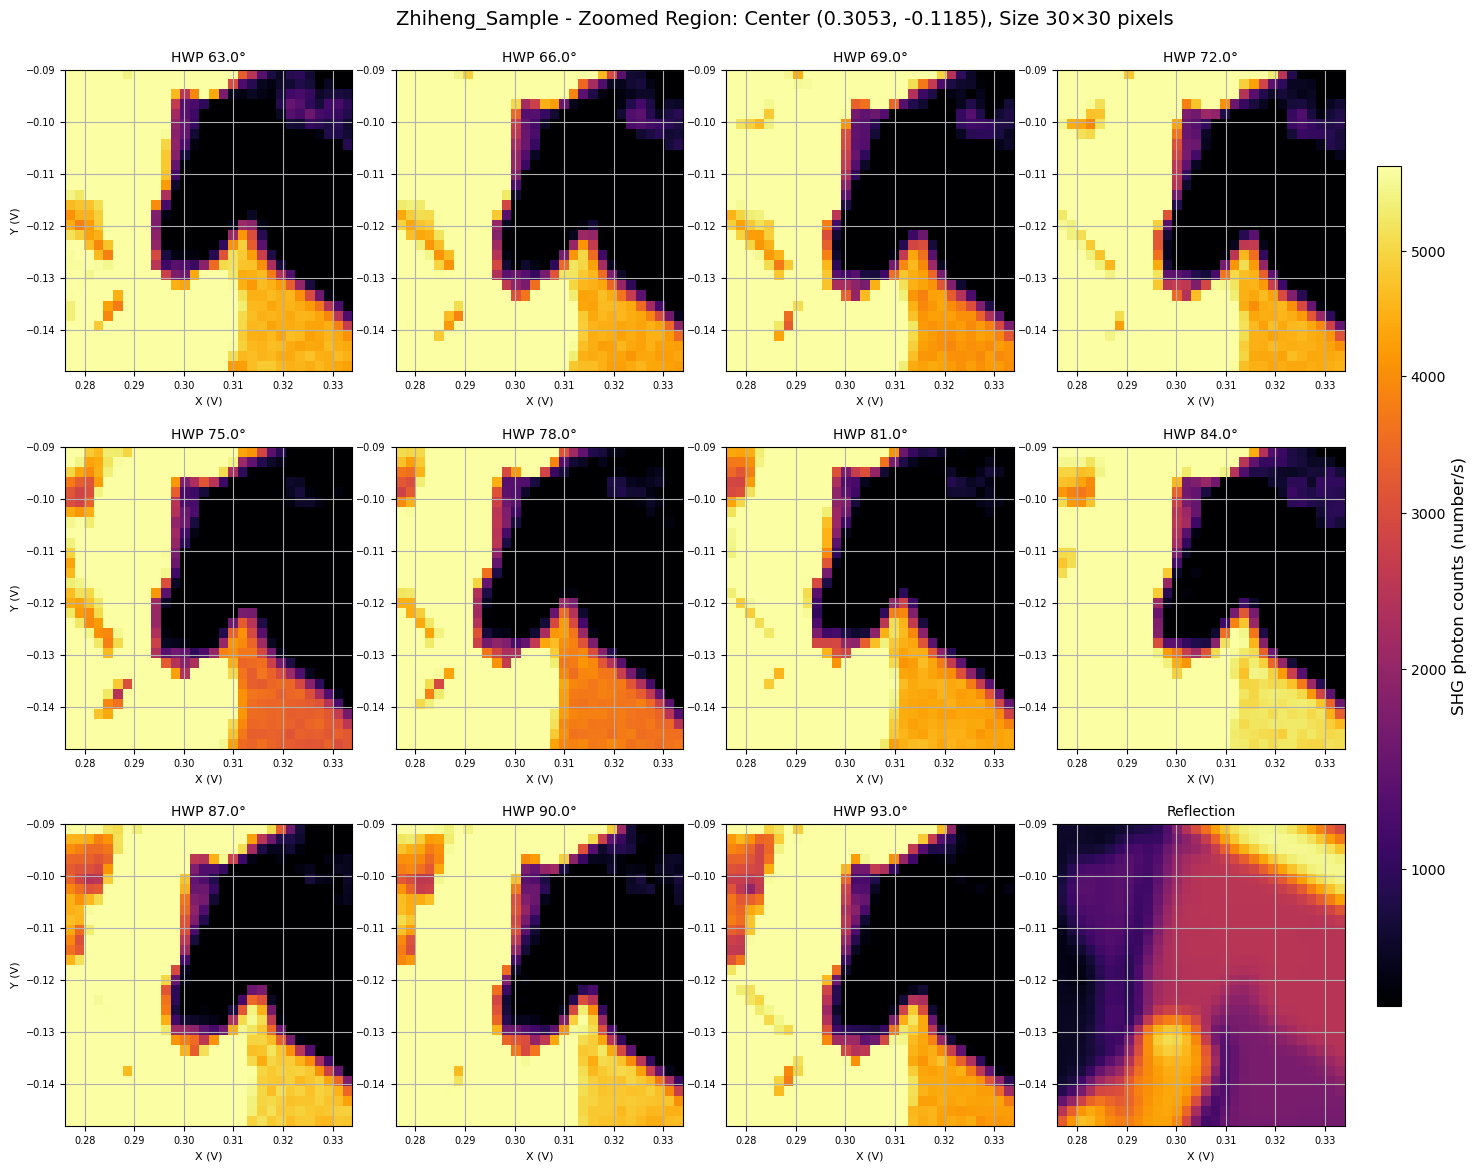

In [289]:
zoom_data = extract_zoom_data(x=0.3053, y=-0.1185, pixel_num=30, count_data=sample_cube_count, reflection_data=sample_cube_ai0)

# Plot the extracted data with default settings
fig1 = plot_zoom_data(zoom_data, count_min=30, count_max=60)



Analyzing shifts relative to image 0 (HWP 63.0°)
------------------------------------------------------------
Image  0 (HWP  63.0°): Reference image
[ 0.9056884  -0.99123664]
Image  1 (HWP  66.0°): Shift = (  0.91,  -0.99) pixels, ( 0.0018, -0.0020) V, Corr = 0.000
[ 1.23344728 -1.48014733]
Image  2 (HWP  69.0°): Shift = (  1.23,  -1.48) pixels, ( 0.0025, -0.0030) V, Corr = 0.000
[ 1.10626455 -1.6497031 ]
Image  3 (HWP  72.0°): Shift = (  1.11,  -1.65) pixels, ( 0.0022, -0.0033) V, Corr = 0.000
[ 0.1276246  -1.15590447]
Image  4 (HWP  75.0°): Shift = (  0.13,  -1.16) pixels, ( 0.0003, -0.0023) V, Corr = 0.000
[-0.97425601 -0.30013863]
Image  5 (HWP  78.0°): Shift = ( -0.97,  -0.30) pixels, (-0.0019, -0.0006) V, Corr = 0.000
[-0.43501782  0.15424684]
Image  6 (HWP  81.0°): Shift = ( -0.44,   0.15) pixels, (-0.0009,  0.0003) V, Corr = 0.000
[ 0.51608991 -0.58445995]
Image  7 (HWP  84.0°): Shift = (  0.52,  -0.58) pixels, ( 0.0010, -0.0012) V, Corr = 0.000
[ 1.15187179 -1.37174971]
Image

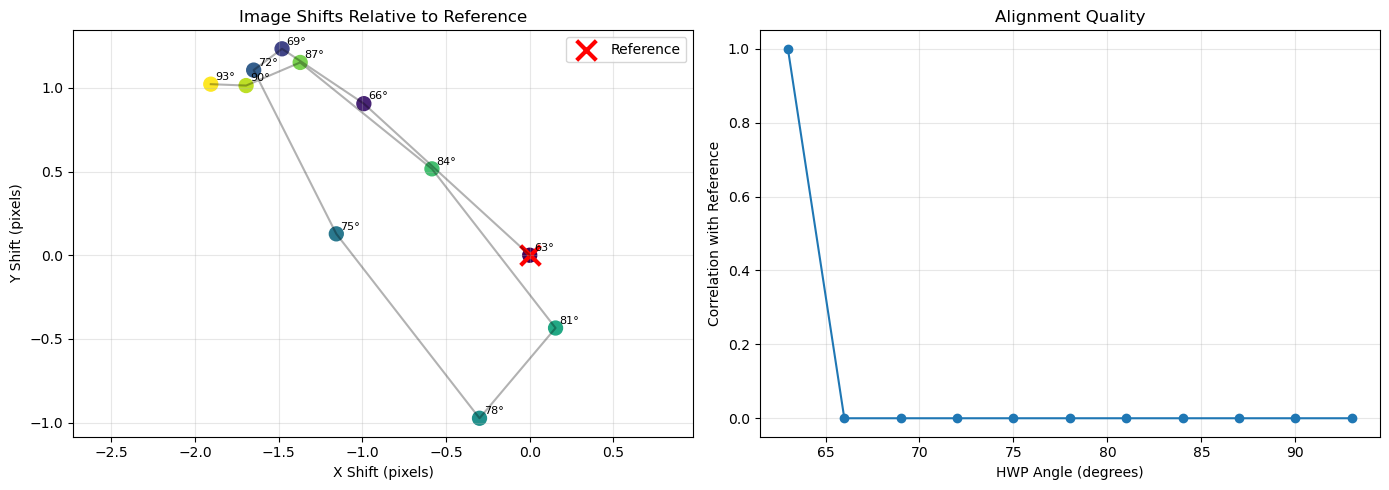

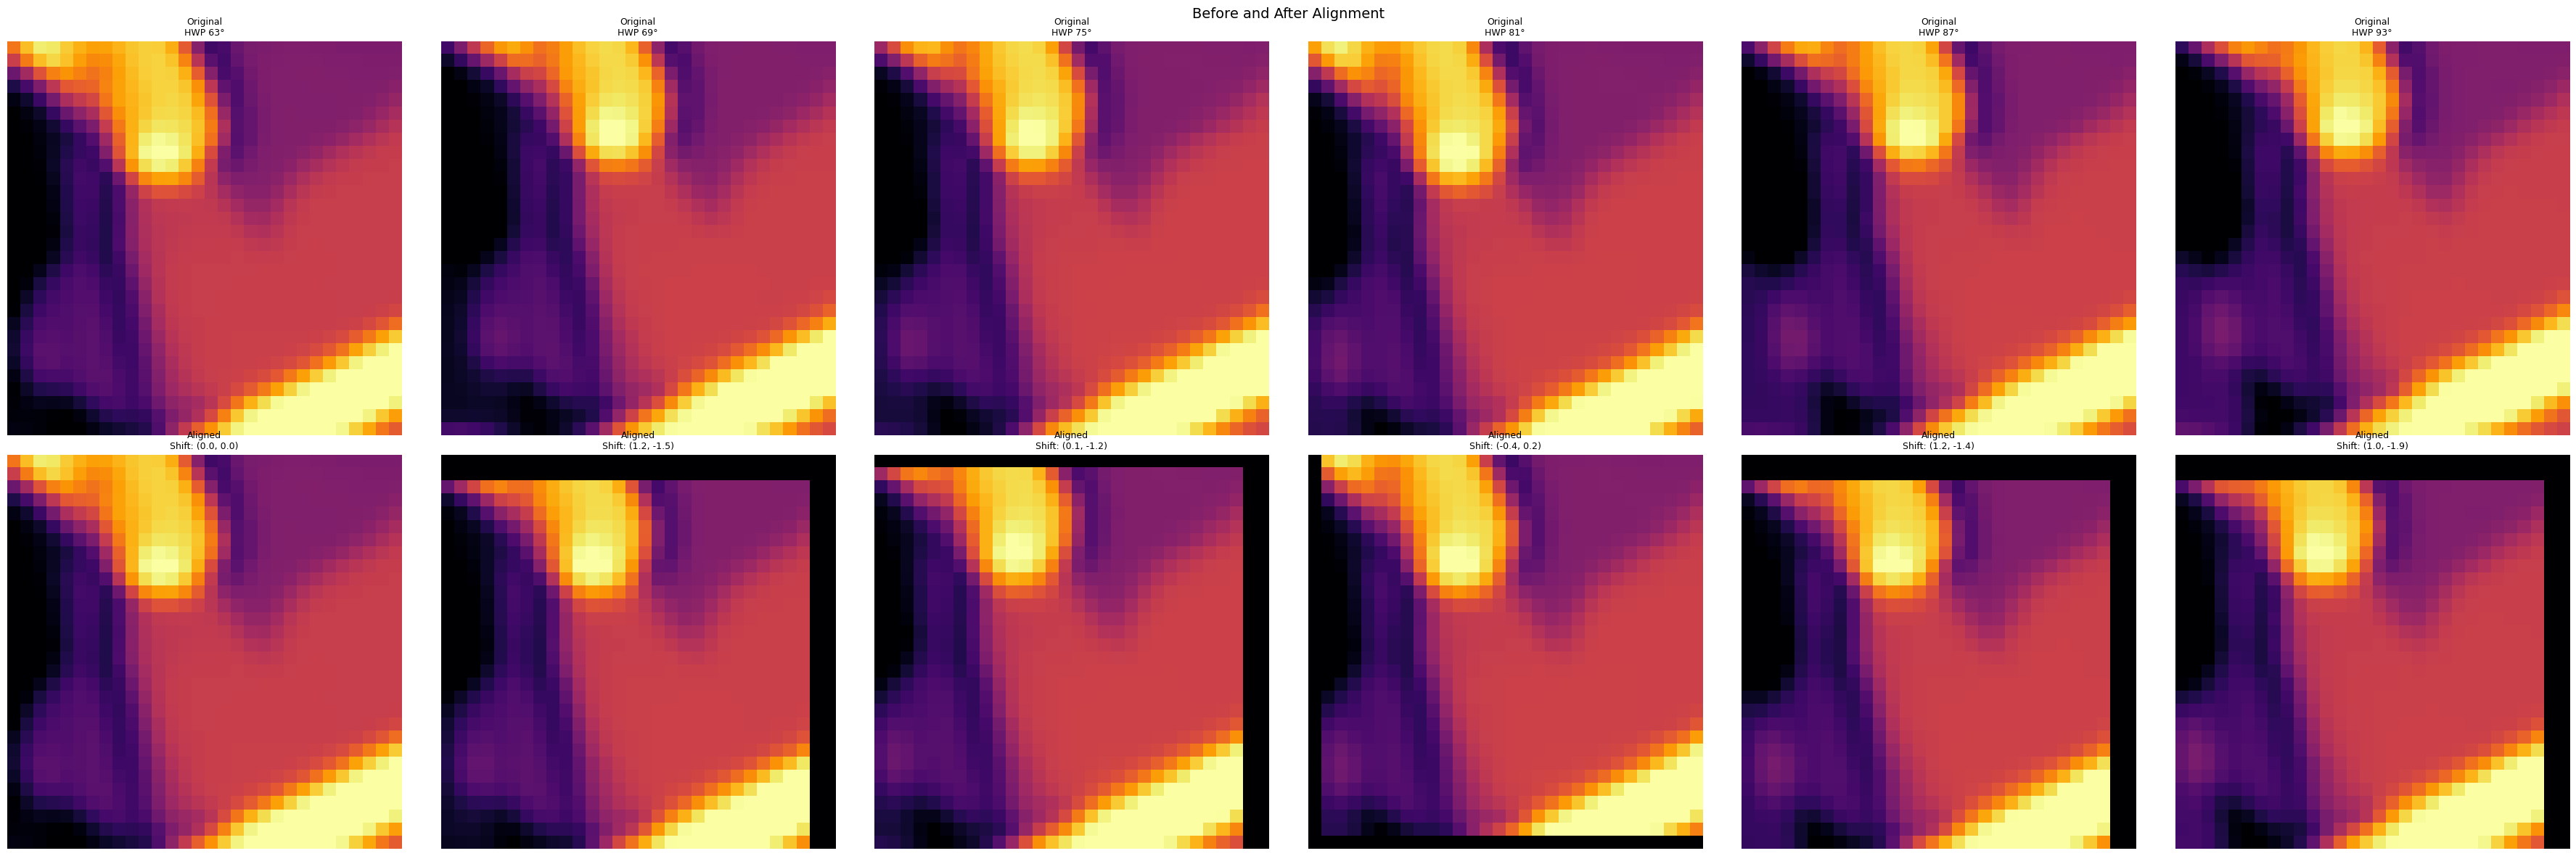

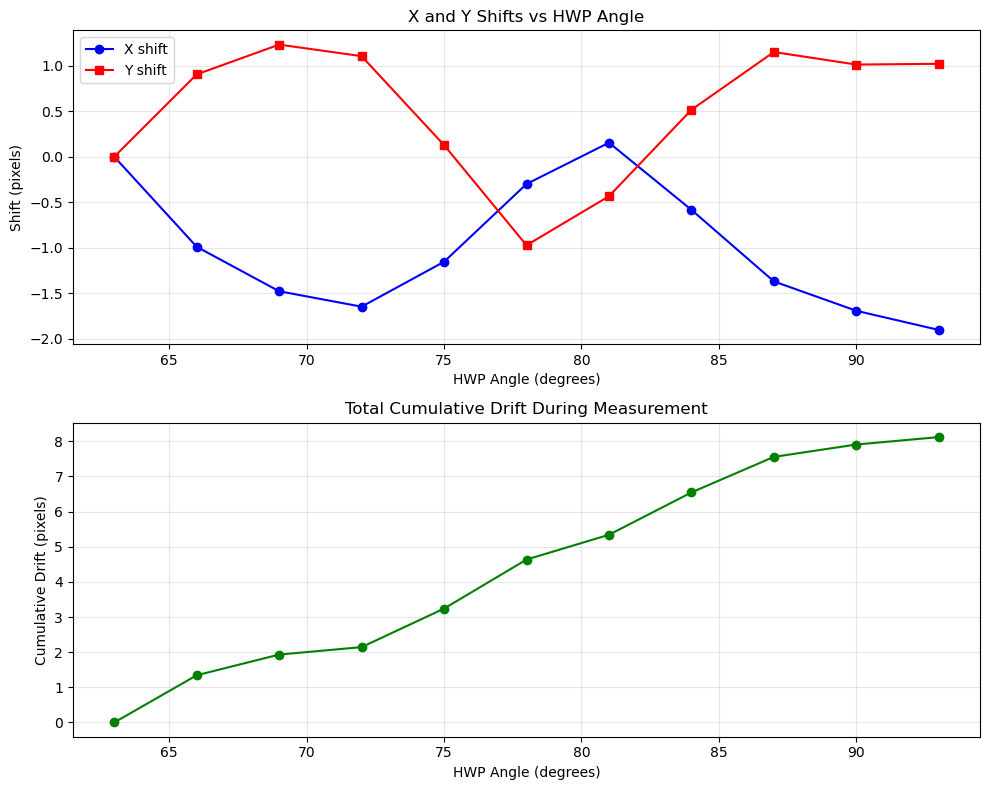


SHIFT ANALYSIS SUMMARY
 HWP Angle (°)  Y Shift (px)  X Shift (px)  Y Shift (V)  X Shift (V)  Total Shift (px)  Correlation
          63.0      0.000000      0.000000     0.000000     0.000000          0.000000          1.0
          66.0      0.905688     -0.991237     0.001811    -0.001982          1.342692          0.0
          69.0      1.233447     -1.480147     0.002467    -0.002960          1.926714          0.0
          72.0      1.106265     -1.649703     0.002213    -0.003299          1.986288          0.0
          75.0      0.127625     -1.155904     0.000255    -0.002312          1.162929          0.0
          78.0     -0.974256     -0.300139    -0.001949    -0.000600          1.019440          0.0
          81.0     -0.435018      0.154247    -0.000870     0.000308          0.461555          0.0
          84.0      0.516090     -0.584460     0.001032    -0.001169          0.779706          0.0
          87.0      1.151872     -1.371750     0.002304    -0.002743        

In [290]:
num_analyze = min(11, len(angles))
data_subset = zoom_data["reflection_zoomed"][:num_analyze]
angles_subset = angles[:num_analyze]

# Perform shift analysis
shifts, correlations, aligned_cube_ai0 = analyze_all_shifts(
    data_subset, 
    reference_idx=0,  # Use first image as reference
    show_plots=True
)

# Create summary report
shift_df = create_shift_report(shifts, correlations, angles_subset)


Square extraction info:
  Requested center: (0.3020, -0.1200)
  Requested size: 3x3
  Extract type: Odd (pixel-centered)
  Center pixel indices: (13, 14)
  Actual extracted size: 3x3 (width x height)
  Pixel bounds: X[12:15], Y[13:16]
  Square bounds (voltage): X[0.2992, 0.3050], Y[-0.1229, -0.1171]


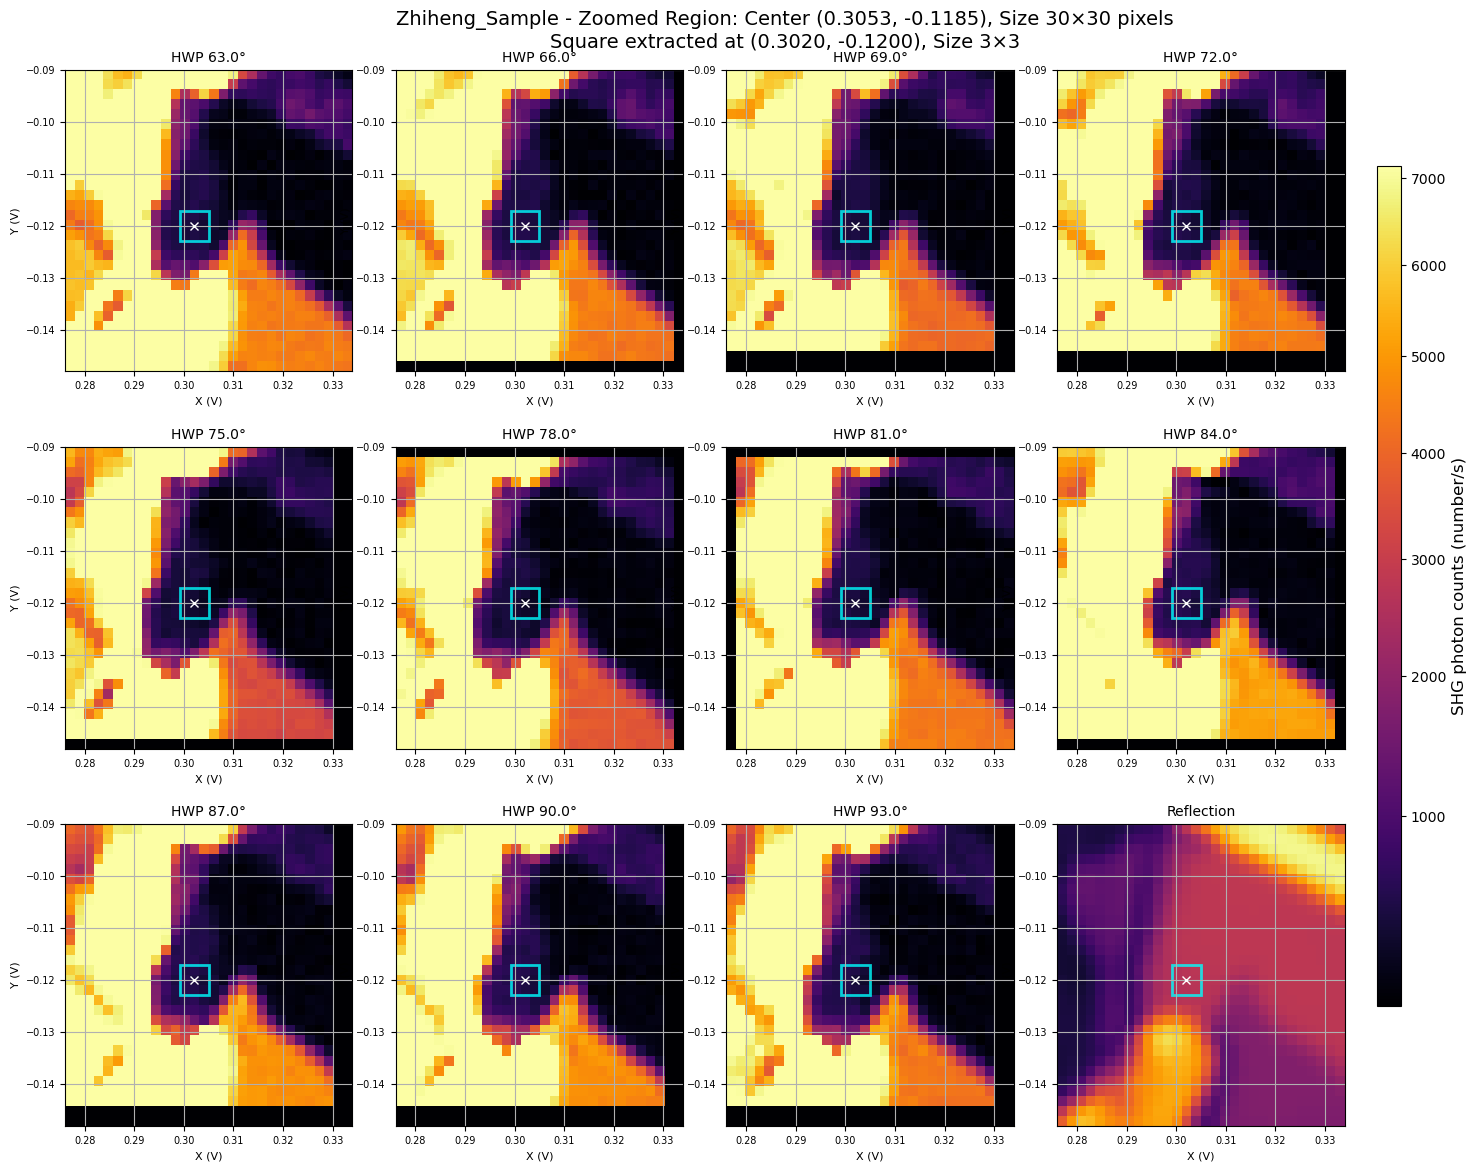

Fitted Parameters: 58.67 * Cos(6 * (x + -0.1326)) + 455.65


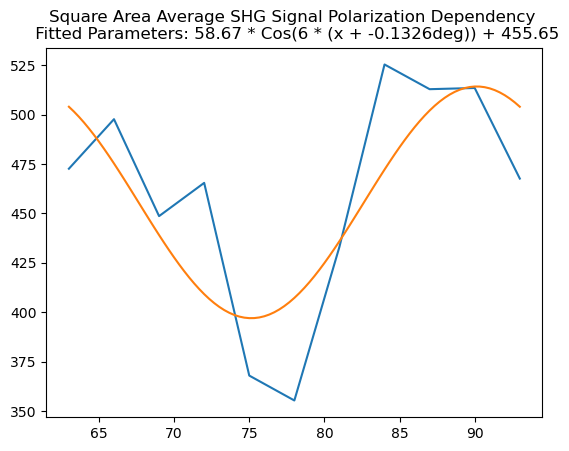

In [291]:
aligned_zoom_data = copy.deepcopy(zoom_data)
aligned_zoom_data["reflection_zoomed"] = aligned_cube_ai0
# aligned_zoom_data["zoomed_data"] = aligned_cube_ai0

negative_shifts = []
for i in range(len(shifts)):
    negative_shifts.append((shifts[i][0], shifts[i][1]))
    # negative_shifts.append((0,0))

aligned_zoom_data["zoomed_data"] = apply_shift_cube(aligned_zoom_data["zoomed_data"], negative_shifts)

fig, cube_data = plot_zoom_data(aligned_zoom_data, count_min=10, count_max=70, extract_x=0.302, extract_y=-0.12, extract_n=3)

fig.savefig(f"{batch_name}_aligned_zoom_data.png", dpi=300, bbox_inches='tight')


average_cube = cube_data.mean(axis=(1,2))
rad_angles = angles / 180 * np.pi
p0 = [200, 0, 200]
params, covariance = curve_fit(model, rad_angles, average_cube, p0=p0, maxfev = 10000)
print(f"Fitted Parameters: {params[0]:.2f} * Cos(6 * (x + {params[1]*180/np.pi:.4f})) + {params[2]:.2f}")
plt.plot(angles, average_cube)
plt.plot(np.linspace(angles[0], angles[-1], 91), model(np.linspace(rad_angles[0], rad_angles[-1], 91), *params))
plt.title(f"Square Area Average SHG Signal Polarization Dependency \n Fitted Parameters: {params[0]:.2f} * Cos(6 * (x + {params[1]*180/np.pi:.4f}deg)) + {params[2]:.2f}")
plt.show()


Extracted zoom data:
  Center coordinates: (0.2000, -0.1600)
  Pixel indices: x[50:110], y[0:50]
  Voltage range: X[0.1400, 0.2580], Y[-0.2000, -0.1020]
  Actual extracted size: 60×50 pixels
  Number of angles extracted: 11


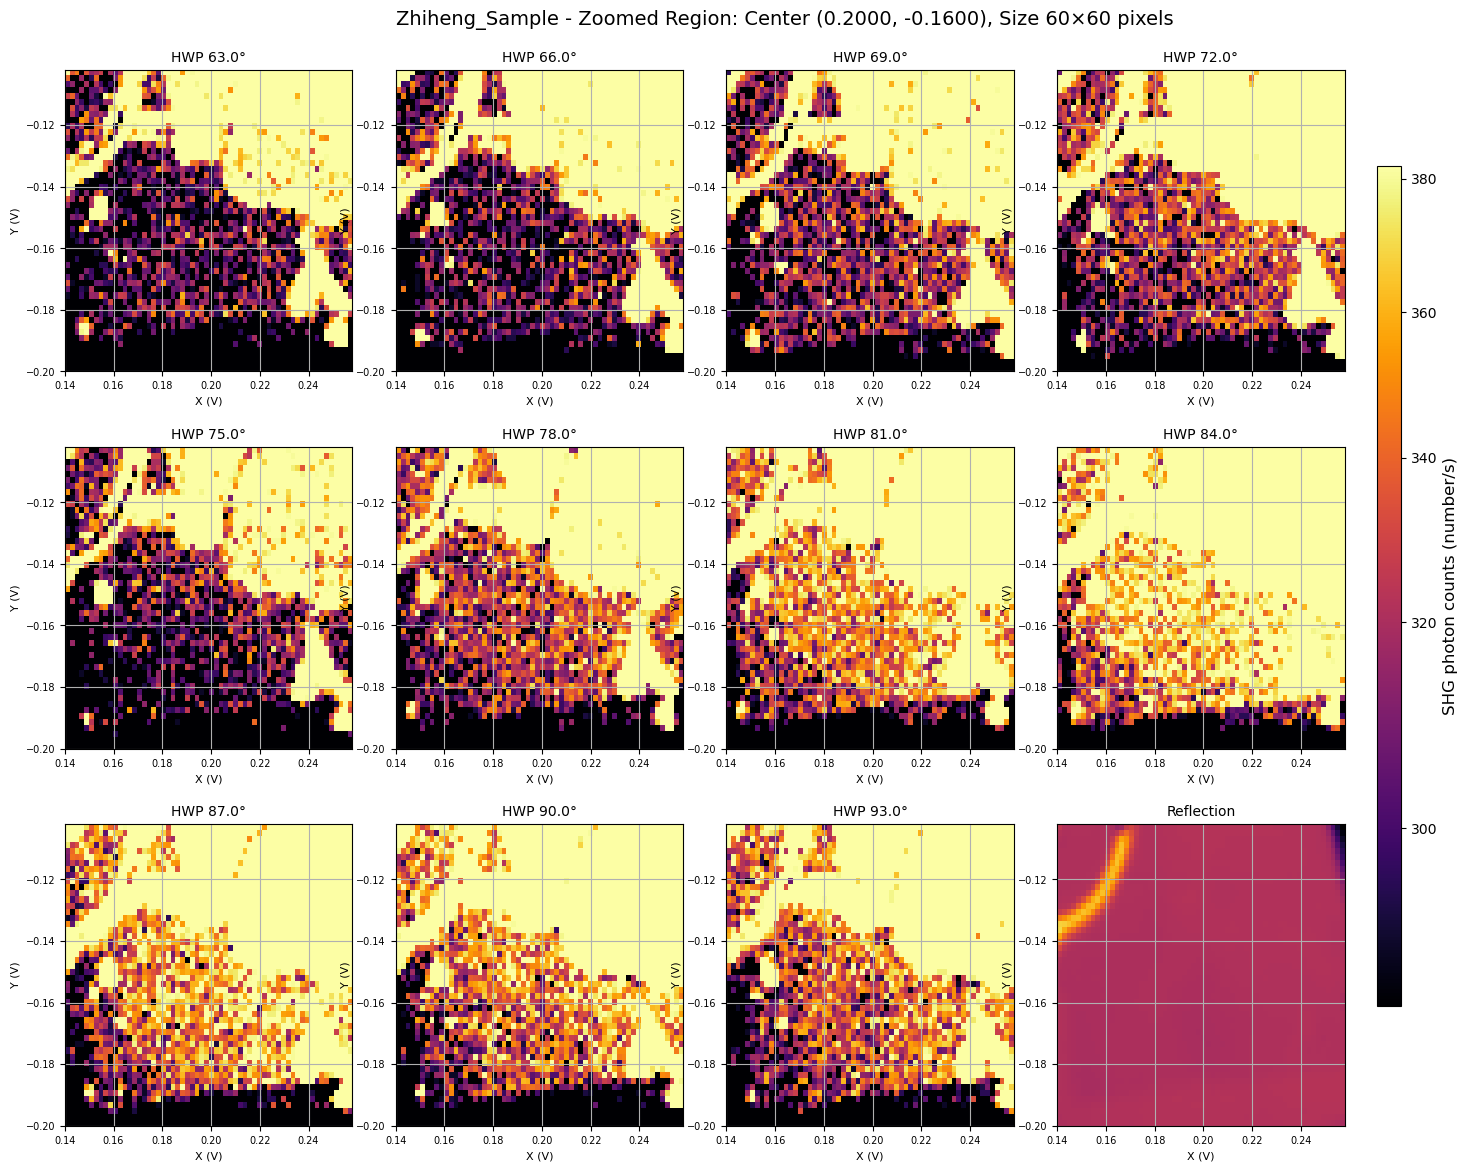


Analyzing shifts relative to image 0 (HWP 63.0°)
------------------------------------------------------------
Image  0 (HWP  63.0°): Reference image
[ 1.3411195  -1.20646413]
Image  1 (HWP  66.0°): Shift = (  1.34,  -1.21) pixels, ( 0.0027, -0.0024) V, Corr = 0.000
[ 1.61589954 -1.75858522]
Image  2 (HWP  69.0°): Shift = (  1.62,  -1.76) pixels, ( 0.0032, -0.0035) V, Corr = 0.000
[ 1.69642887 -1.94869595]
Image  3 (HWP  72.0°): Shift = (  1.70,  -1.95) pixels, ( 0.0034, -0.0039) V, Corr = 0.000
[ 0.4824412  -1.23414467]
Image  4 (HWP  75.0°): Shift = (  0.48,  -1.23) pixels, ( 0.0010, -0.0025) V, Corr = 0.000
[-0.43202614 -0.13821439]
Image  5 (HWP  78.0°): Shift = ( -0.43,  -0.14) pixels, (-0.0009, -0.0003) V, Corr = 0.000
[0.10321963 0.12440385]
Image  6 (HWP  81.0°): Shift = (  0.10,   0.12) pixels, ( 0.0002,  0.0002) V, Corr = 0.000
[ 1.47907356 -0.95296732]
Image  7 (HWP  84.0°): Shift = (  1.48,  -0.95) pixels, ( 0.0030, -0.0019) V, Corr = 0.000
[ 1.83240733 -1.6314696 ]
Image  

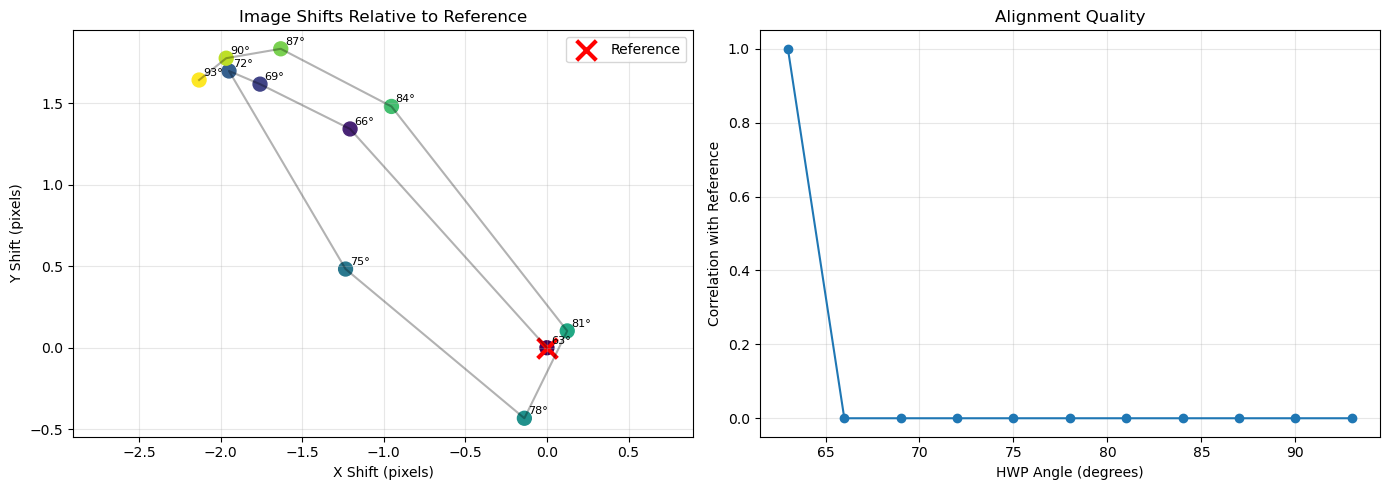

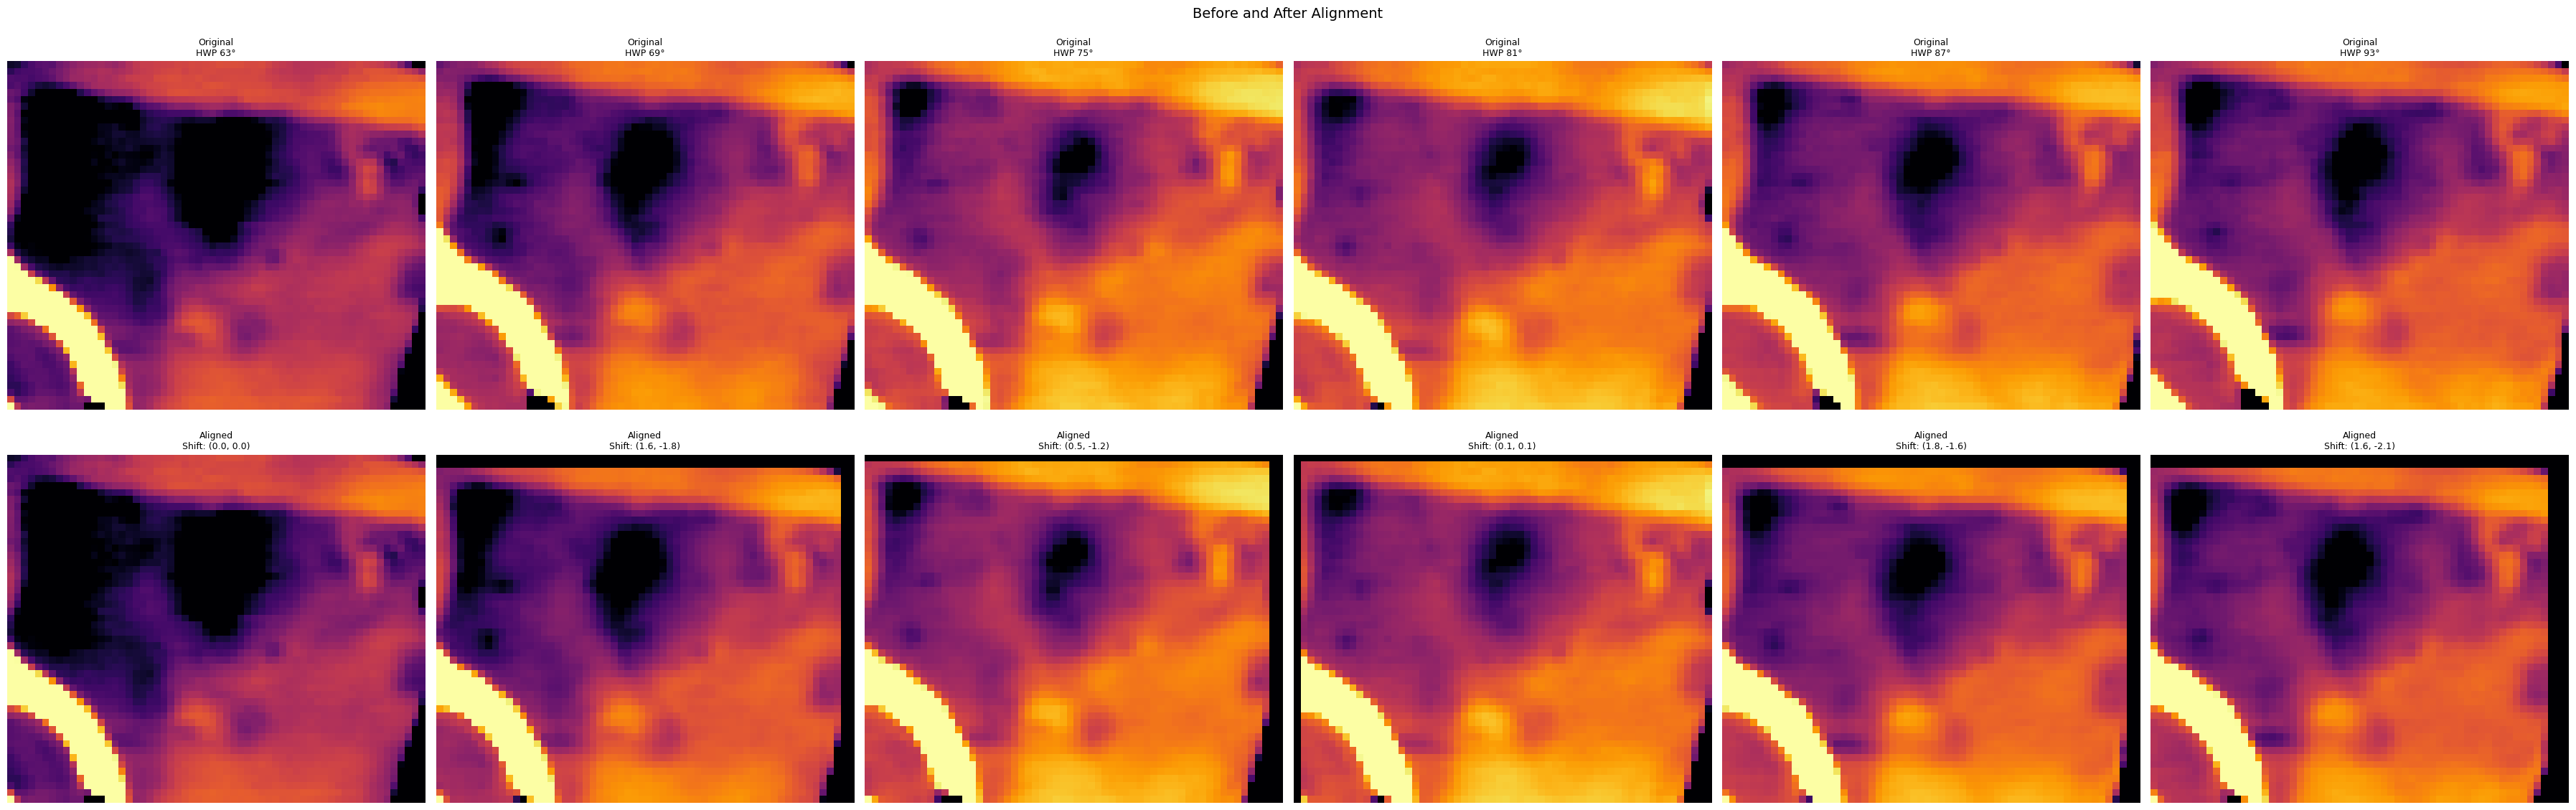

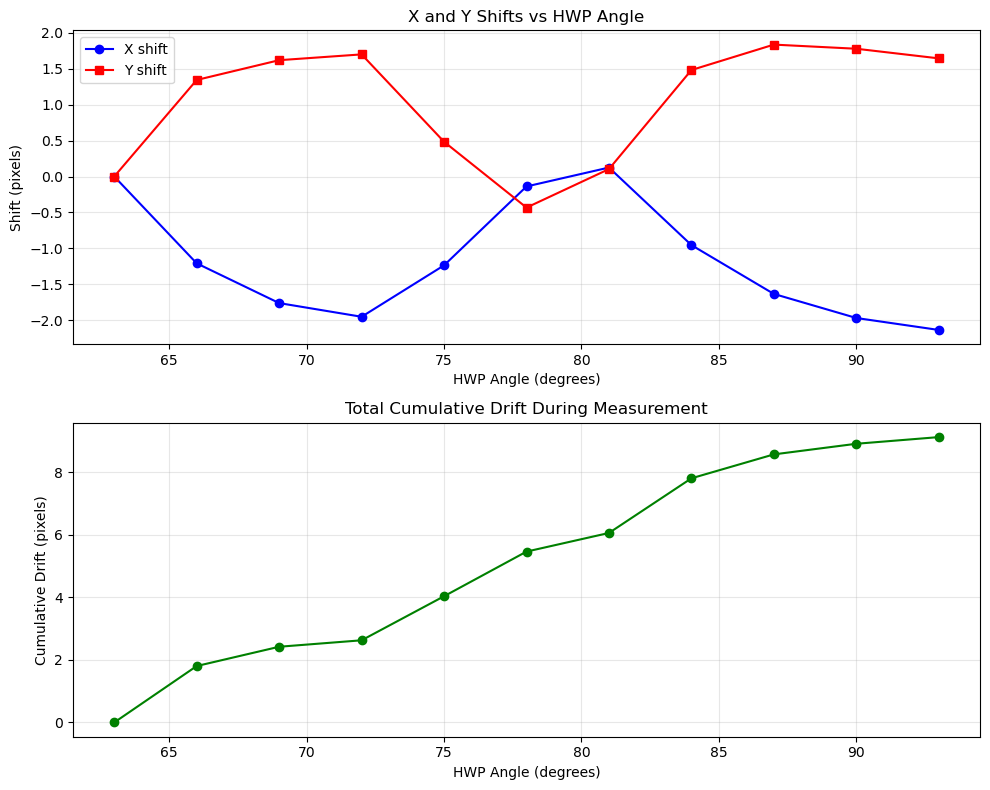


SHIFT ANALYSIS SUMMARY
 HWP Angle (°)  Y Shift (px)  X Shift (px)  Y Shift (V)  X Shift (V)  Total Shift (px)  Correlation
          63.0      0.000000      0.000000     0.000000     0.000000          0.000000          1.0
          66.0      1.341119     -1.206464     0.002682    -0.002413          1.803928          0.0
          69.0      1.615900     -1.758585     0.003232    -0.003517          2.388253          0.0
          72.0      1.696429     -1.948696     0.003393    -0.003897          2.583658          0.0
          75.0      0.482441     -1.234145     0.000965    -0.002468          1.325090          0.0
          78.0     -0.432026     -0.138214    -0.000864    -0.000276          0.453597          0.0
          81.0      0.103220      0.124404     0.000206     0.000249          0.161650          0.0
          84.0      1.479074     -0.952967     0.002958    -0.001906          1.759490          0.0
          87.0      1.832407     -1.631470     0.003665    -0.003263        

In [278]:
zoom_data = extract_zoom_data(x=0.20, y=-0.16, pixel_num=61, count_data=sample_cube_count, reflection_data=sample_cube_ai0)

# Plot the extracted data with default settings
fig1 = plot_zoom_data(zoom_data, count_min=20, count_max=60)

num_analyze = min(11, len(angles))
data_subset = zoom_data["reflection_zoomed"][:num_analyze]
angles_subset = angles[:num_analyze]

# Perform shift analysis
shifts, correlations, aligned_cube_ai0 = analyze_all_shifts(
    data_subset, 
    reference_idx=0,  # Use first image as reference
    show_plots=True
)

# Create summary report
shift_df = create_shift_report(shifts, correlations, angles_subset)


Square extraction info:
  Requested center: (0.1830, -0.1600)
  Requested size: 15x15
  Extract type: Odd (pixel-centered)
  Center pixel indices: (22, 20)
  Actual extracted size: 15x15 (width x height)
  Pixel bounds: X[15:30], Y[13:28]
  Square bounds (voltage): X[0.1695, 0.1990], Y[-0.1745, -0.1451]


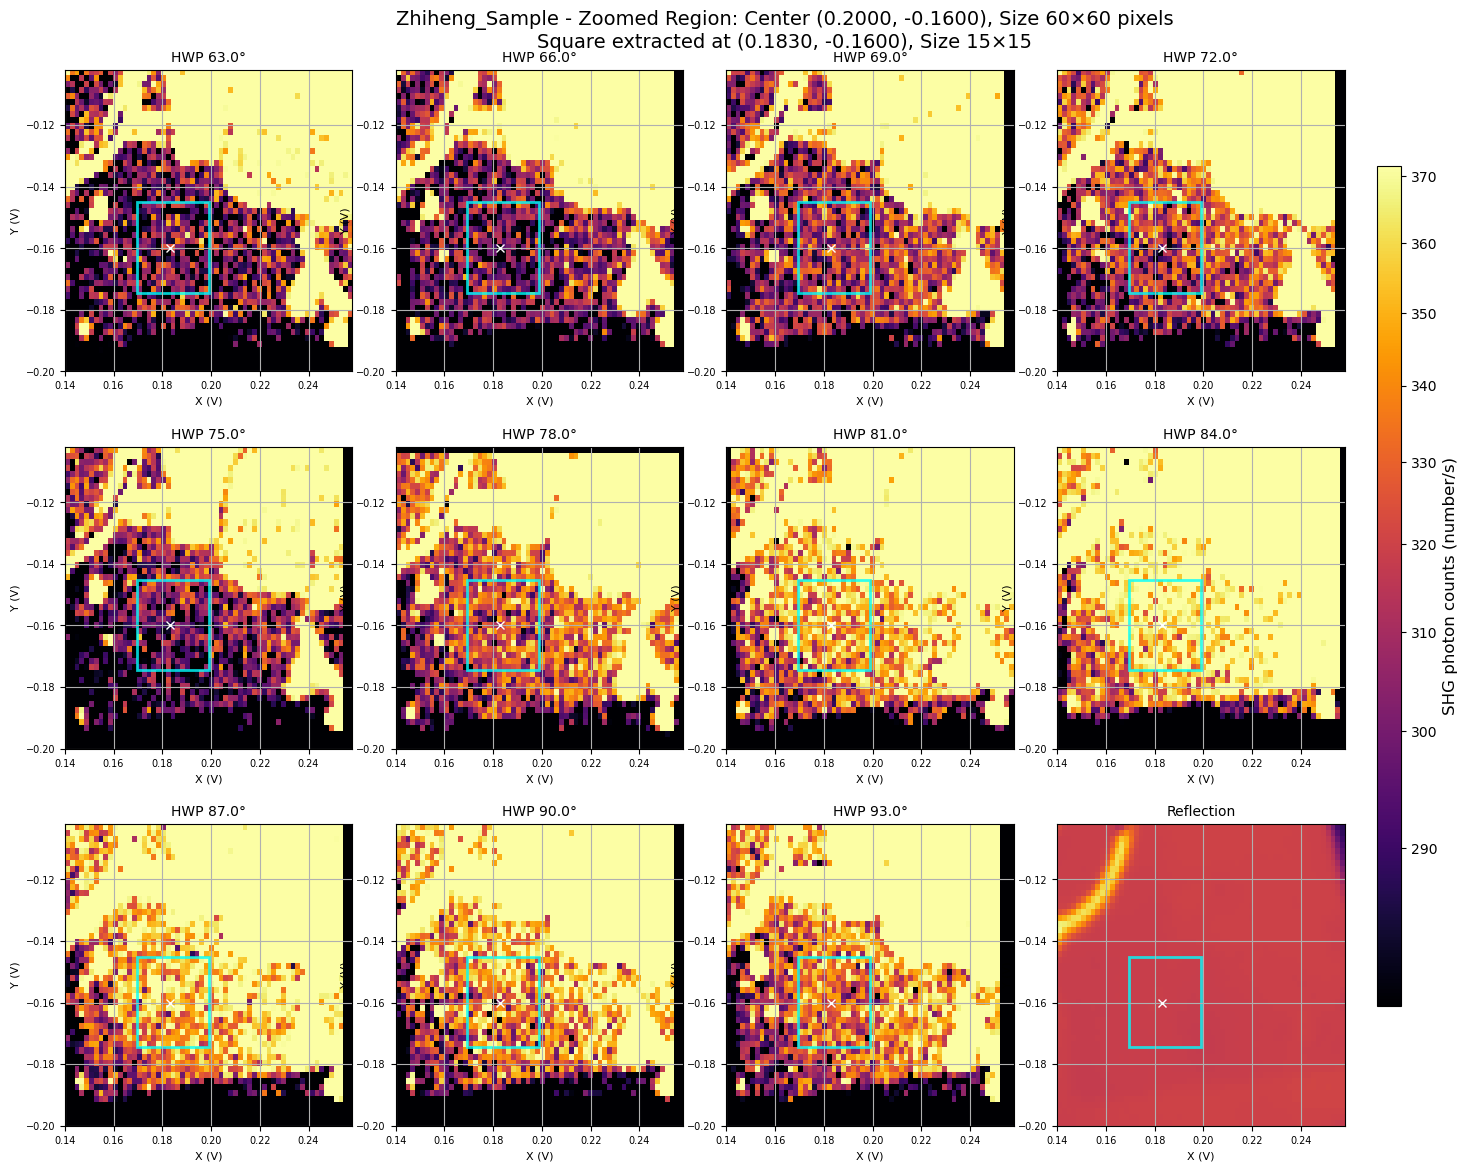

Fitted Parameters: 30.03 * Cos(6 * (x + 5.4088)) + 327.05


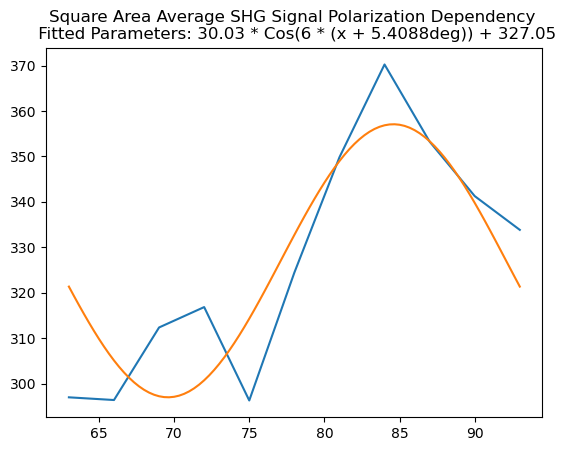

In [287]:
aligned_zoom_data = copy.deepcopy(zoom_data)
aligned_zoom_data["reflection_zoomed"] = aligned_cube_ai0
# aligned_zoom_data["zoomed_data"] = aligned_cube_ai0

negative_shifts = []
for i in range(len(shifts)):
    negative_shifts.append((shifts[i][0], shifts[i][1]))
    # negative_shifts.append((0,0))

aligned_zoom_data["zoomed_data"] = apply_shift_cube(aligned_zoom_data["zoomed_data"], negative_shifts)

fig, cube_data = plot_zoom_data(aligned_zoom_data, count_min=20, count_max=60, extract_x=0.183, extract_y=-0.16, extract_n=15)

fig.savefig(f"{batch_name}_aligned_zoom_data.png", dpi=300, bbox_inches='tight')


average_cube = cube_data.mean(axis=(1,2))
rad_angles = angles / 180 * np.pi
p0 = [200, 0, 200]
params, covariance = curve_fit(model, rad_angles, average_cube, p0=p0, maxfev = 10000)
print(f"Fitted Parameters: {params[0]:.2f} * Cos(6 * (x + {params[1]*180/np.pi:.4f})) + {params[2]:.2f}")
plt.plot(angles, average_cube)
plt.plot(np.linspace(angles[0], angles[-1], 91), model(np.linspace(rad_angles[0], rad_angles[-1], 91), *params))
plt.title(f"Square Area Average SHG Signal Polarization Dependency \n Fitted Parameters: {params[0]:.2f} * Cos(6 * (x + {params[1]*180/np.pi:.4f}deg)) + {params[2]:.2f}")
plt.show()

In [292]:
batch_name = 'Zhiheng_Sample'

# ------------------------------------------------------------------
# 1)  Load the file and pull out the pieces we need
# ------------------------------------------------------------------
DATAFILE = Path("0112_SHG_map_polardep.json")   # adjust as needed

with DATAFILE.open() as f:
    j = json.load(f)

# x- and y-axes (set points for the two analogue outputs)
x_vals = np.asarray(j["levels"]["level0"]["setting_array"][0])   # nidaq_0_AO0  (81 pts)
y_vals = np.asarray(j["levels"]["level1"]["setting_array"][0])   # nidaq_0_AO1  (81 pts)

# HWP angles - use for titles / filenames
angles = np.asarray(j["levels"]["level2"]["setting_array"][0])
LP_angles = np.asarray(j["levels"]["level2"]["setting_array"][1])

# sample-count cube: shape = (number_of_angles, 81 y, 81 x)
sample_cube_ai0 = np.asarray(j["data"][0][0])
sample_cube_count = np.asarray(j["data"][0][1])   

print(f"Total number of angles available: {len(angles)}")
print(f"Available angles: {angles}")

Total number of angles available: 61
Available angles: [-12.  -9.  -6.  -3.   0.   3.   6.   9.  12.  15.  18.  21.  24.  27.
  30.  33.  36.  39.  42.  45.  48.  51.  54.  57.  60.  63.  66.  69.
  72.  75.  78.  81.  84.  87.  90.  93.  96.  99. 102. 105. 108. 111.
 114. 117. 120. 123. 126. 129. 132. 135. 138. 141. 144. 147. 150. 153.
 156. 159. 162. 165. 168.]


In [ ]:
angles[25:37]

array([63., 66., 69., 72., 75., 78., 81., 84., 87., 90.])

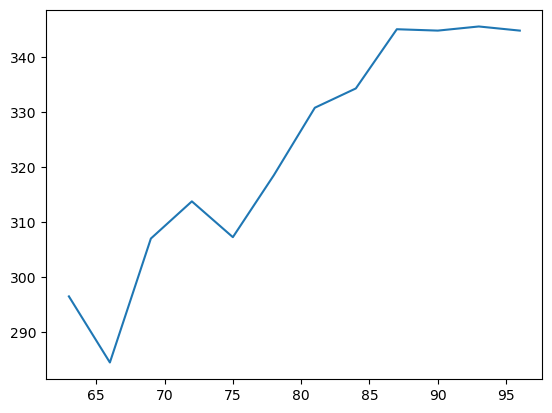

In [ ]:
plt.plot(angles[25:37], sample_cube_count[:,1:-1,1:-1].mean(axis=(1,2))[25:37])
plt.show()

<ErrorbarContainer object of 3 artists>

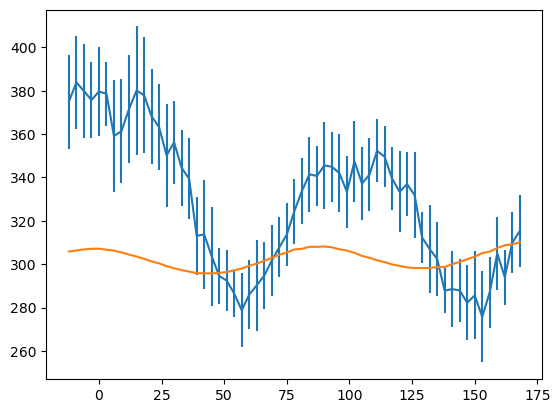

In [312]:
plt.errorbar(angles, sample_cube_count[:,1:-1,1:-1].mean(axis=(1,2)), yerr=sample_cube_count[:,1:-1,1:-1].std(axis=(1,2)))
plt.errorbar(angles, 300*sample_cube_ai0[:,1:-1,1:-1].mean(axis=(1,2)), yerr=sample_cube_ai0[:,1:-1,1:-1].std(axis=(1,2)))

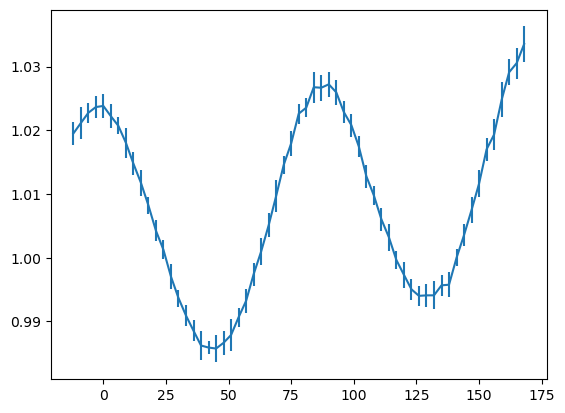

In [310]:
plt.errorbar(angles, sample_cube_ai0[:,1:-1,1:-1].mean(axis=(1,2)), yerr=sample_cube_ai0[:,1:-1,1:-1].std(axis=(1,2)))
plt.show()